# CS-4982 — High-Stakes Hedging Detection
### Progress Report 2 — Implementation Simulation
**Author:** Darin Thomson | Student ID: 3776723 | UNBSJ

**Date:** March 1st, 2026

---

## Overview

1. **Data Setup** — Synthetic financial data + mock EDGAR-style text disclosures
2. **Hedging Index Construction** — Composite score from financial + linguistic signals
3. **Visualization Dashboard** — Risk profiling, hedging trends, and company comparison
4. **Failure Risk Scoring** — Simple threshold-based early warning output

---

## Section 1: Imports & Configuration

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import re
from collections import Counter

warnings.filterwarnings('ignore')

#Styling
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#c9d1e0',
    'xtick.color':      '#8892a4',
    'ytick.color':      '#8892a4',
    'text.color':       '#c9d1e0',
    'grid.color':       '#2a2d3d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

PALETTE = ['#4fc3f7', '#81c784', '#ffb74d', '#e57373', '#ce93d8', '#4dd0e1']
RISK_COLORS = {'Low': '#81c784', 'Medium': '#ffb74d', 'High': '#e57373', 'Critical': '#c62828'}

np.random.seed(42)
print("✓ Environment configured.")

✓ Environment configured.


---
## Section 2: Data Generation

We simulate **8 publicly traded companies** across 3 sectors with **12 quarters** of financial data each.  
Each company has a distinct underlying health profile (healthy / distressed / failed), allowing us to test our hedging index against known outcomes.

Data mirrors what would be pulled from **EDGAR** (10-K / 10-Q filings) and includes:
- Standard financial ratios (PE, Debt/Equity, etc.)
- Synthetic MD&A text excerpts with varying degrees of hedging language

In [19]:
#Company Master
companies = [
    {'ticker': 'ALPH', 'name': 'Alpha Capital',      'sector': 'Hedge Fund',   'profile': 'healthy'},
    {'ticker': 'BRVX', 'name': 'Bravex Asset Mgmt',  'sector': 'Hedge Fund',   'profile': 'distressed'},
    {'ticker': 'CRUX', 'name': 'Crux Investments',   'sector': 'Hedge Fund',   'profile': 'failed'},
    {'ticker': 'DELT', 'name': 'Delta Quantitative', 'sector': 'Quant Fund',   'profile': 'healthy'},
    {'ticker': 'ECHO', 'name': 'Echo Global Fund',   'sector': 'Quant Fund',   'profile': 'distressed'},
    {'ticker': 'FLUX', 'name': 'Flux Money Mgmt',    'sector': 'Mutual Fund',  'profile': 'healthy'},
    {'ticker': 'GRVY', 'name': 'Gravity Partners',   'sector': 'Mutual Fund',  'profile': 'distressed'},
    {'ticker': 'HRZN', 'name': 'Horizon Wealth',     'sector': 'Mutual Fund',  'profile': 'failed'},
]

quarters = pd.date_range(start='2022-Q1', periods=12, freq='QE')

#Financial Ratio Generator
def gen_financials(profile, n=12):
    """Generate quarterly financial ratios shaped by company health profile."""
    trends = {
        'healthy':    {'pe': (15, 2),   'de': (0.4, 0.05), 'roe': (0.18, 0.02), 'current': (2.2, 0.2)},
        'distressed': {'pe': (8,  3),   'de': (1.8, 0.3),  'roe': (0.04, 0.05), 'current': (1.1, 0.3)},
        'failed':     {'pe': (3,  4),   'de': (4.5, 0.8),  'roe': (-0.12, 0.1), 'current': (0.6, 0.2)},
    }[profile]

    drift = np.linspace(0, 1, n)  # values deteriorate over time for distressed/failed
    sign  = -1 if profile != 'healthy' else 0

    pe      = np.maximum(1, trends['pe'][0]  + sign * drift * 4  + np.random.normal(0, trends['pe'][1],  n))
    de      = np.maximum(0, trends['de'][0]  - sign * drift * 1.5 + np.random.normal(0, trends['de'][1],  n))
    roe     = trends['roe'][0] + sign * drift * 0.15 + np.random.normal(0, trends['roe'][1], n)
    current = np.maximum(0.1, trends['current'][0] + sign * drift * 0.8 + np.random.normal(0, trends['current'][1], n))

    return pe, de, roe, current

#Build Master DataFrame
records = []
for c in companies:
    pe, de, roe, cur = gen_financials(c['profile'])
    for i, q in enumerate(quarters):
        records.append({
            'ticker':  c['ticker'],
            'name':    c['name'],
            'sector':  c['sector'],
            'profile': c['profile'],
            'quarter': q,
            'pe_ratio':      round(pe[i], 2),
            'debt_equity':   round(de[i], 2),
            'roe':           round(roe[i], 4),
            'current_ratio': round(cur[i], 2),
        })

df = pd.DataFrame(records)
print(f"✓ Financial dataset: {len(df)} rows × {len(df.columns)} columns")
df[df['ticker'] == 'CRUX'].head()

✓ Financial dataset: 96 rows × 9 columns


,ticker,name,sector,profile,quarter,pe_ratio,debt_equity,roe,current_ratio
24,CRUX,Crux Investments,Hedge Fund,failed,2022-03-31,2.49,4.56,-0.1851,0.70
25,CRUX,Crux Investments,Hedge Fund,failed,2022-06-30,1.00,3.95,-0.1823,0.33
26,CRUX,Crux Investments,Hedge Fund,failed,2022-09-30,1.00,5.99,-0.2065,0.47
27,CRUX,Crux Investments,Hedge Fund,failed,2022-12-31,2.72,5.34,-0.2473,0.53
28,CRUX,Crux Investments,Hedge Fund,failed,2023-03-31,1.00,4.22,-0.1697,0.10


In [18]:
# ── MD&A Text Disclosure Simulation
# Mirrors what would be scraped from EDGAR 10-K/10-Q filings
# Healthy firms use clear, confident language; distressed firms use hedging language

LOUGHRAN_MCDONALD_HEDGING = [
    'approximately', 'generally', 'may', 'might', 'could', 'would', 'should',
    'possibly', 'potentially', 'subject to', 'uncertainty', 'uncertain',
    'believe', 'expect', 'anticipate', 'estimate', 'intend', 'plan',
    'depends', 'contingent', 'pending', 'if', 'although', 'however',
    'challenging', 'volatile', 'difficult', 'risk', 'risks', 'no assurance',
    'may not', 'cannot guarantee', 'limited visibility', 'unclear',
    'we cannot predict', 'there can be no assurance'
]

# Pre-defined disclosure templates with varying hedging intensity
DISCLOSURES = {
    'healthy': [
        "Revenue increased 14% year-over-year, driven by strong performance across all segments. "
        "Operating margins expanded to 22%. The balance sheet remains robust with cash reserves of $2.1B.",

        "Our diversified portfolio delivered consistent returns. Net income rose 11% to $340M. "
        "We are confident in our capital allocation strategy and expect continued growth.",
    ],
    'distressed': [
        "Revenue may be impacted by challenging market conditions. We believe performance could "
        "potentially improve although uncertainty remains. Results are subject to volatile conditions "
        "and may not reflect prior expectations. There can be no assurance of future outcomes.",

        "We anticipate approximately stable conditions although the environment remains difficult. "
        "Operating results might be impacted and could possibly decline. We expect uncertainty "
        "to persist and cannot guarantee prior performance levels will be maintained.",
    ],
    'failed': [
        "Results may be materially impacted by significant uncertainty and volatile market conditions. "
        "We cannot predict outcomes and there can be no assurance. Pending regulatory review, "
        "performance could potentially deteriorate. Risk factors remain uncertain and challenging. "
        "Limited visibility into future quarters. Contingent on market recovery which may not occur.",

        "Uncertain and volatile conditions may potentially impact our ability to meet obligations. "
        "We believe risks are significant although we cannot guarantee stabilization. "
        "Approximately $400M in contingent liabilities subject to review. No assurance of recovery.",
    ]
}

def assign_disclosure(row):
    texts = DISCLOSURES[row['profile']]
    # Alternate between templates per quarter
    return texts[row.name % len(texts)]

df['disclosure_text'] = df.apply(assign_disclosure, axis=1)
print("✓ Disclosure text assigned to all records.")
print("\nSample CRUX (failed) disclosure:")
print("  →", df[df['ticker']=='CRUX'].iloc[0]['disclosure_text'][:120], "...")

✓ Disclosure text assigned to all records.

Sample CRUX (failed) disclosure:
  → Results may be materially impacted by significant uncertainty and volatile market conditions. We cannot predict outcomes ...


---
## Section 3: Hedging Index Construction

The **Hedging Index (HI)** is the core contribution of this project. It is a composite score [0, 1] computed from three sub-components:

| Component | Description | Weight |
|---|---|---|
| **Linguistic Hedging Score (LHS)** | Density of Loughran-McDonald hedging terms in MD&A text | 40% |
| **Financial Overemphasis Score (FOS)** | Gap between reported PE vs. sector median (selective metric emphasis) | 35% |
| **Volatility Score (VS)** | Rolling quarter-over-quarter variance in debt/equity and current ratio | 25% |

A higher HI → greater hedging behavior → higher failure risk.

In [17]:
#3.1 Linguistic Hedging Score
def linguistic_hedging_score(text):
    """Count hedging term density per 100 words (normalized to [0,1])."""
    text_lower = text.lower()
    words = text_lower.split()
    word_count = max(len(words), 1)
    hits = sum(1 for phrase in LOUGHRAN_MCDONALD_HEDGING if phrase in text_lower)
    raw = hits / word_count * 100  # hits per 100 words
    return min(round(raw / 15.0, 4), 1.0)  # normalize: 15+ hits/100w = score of 1.0

df['lhs'] = df['disclosure_text'].apply(linguistic_hedging_score)

# 3.2 Financial Overemphasis Score
# Compare each company's PE to its sector median — high PE vs low real performance = overemphasis
sector_pe_median = df.groupby(['sector', 'quarter'])['pe_ratio'].transform('median')
df['fos'] = ((df['pe_ratio'] / sector_pe_median.clip(lower=1)) - 1).clip(0, 2) / 2
df['fos'] = df['fos'].round(4)

# 3.3 Volatility Score
# Rolling std of debt/equity and current_ratio (2-quarter window)
def volatility_score(group):
    de_vol  = group['debt_equity'].rolling(2, min_periods=1).std().fillna(0)
    cur_vol = group['current_ratio'].rolling(2, min_periods=1).std().fillna(0)
    raw = (de_vol / group['debt_equity'].mean()) + (cur_vol / group['current_ratio'].mean())
    return (raw / raw.max()).clip(0, 1).round(4) if raw.max() > 0 else raw

df['vs'] = df.groupby('ticker', group_keys=False).apply(volatility_score)

# 3.4 Composite Hedging Index
W_LHS, W_FOS, W_VS = 0.40, 0.35, 0.25
df['hedging_index'] = (W_LHS * df['lhs'] + W_FOS * df['fos'] + W_VS * df['vs']).round(4)

# 3.5 Risk Classification
def classify_risk(hi):
    if   hi < 0.25: return 'Low'
    elif hi < 0.45: return 'Medium'
    elif hi < 0.65: return 'High'
    else:           return 'Critical'

df['risk_level'] = df['hedging_index'].apply(classify_risk)

print("✓ Hedging Index computed. Summary by company profile:")
print(df.groupby('profile')[['lhs', 'fos', 'vs', 'hedging_index']].mean().round(3).to_string())

✓ Hedging Index computed. Summary by company profile:
              lhs    fos     vs  hedging_index
profile                                       
distressed  1.000  0.000  0.457          0.514
failed      1.000  0.000  0.362          0.491
healthy     0.278  0.533  0.538          0.432


---
## Section 4: Visualization Dashboard

Four panels visualizing the hedging detection results across companies and time.

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/dashboard1.png'

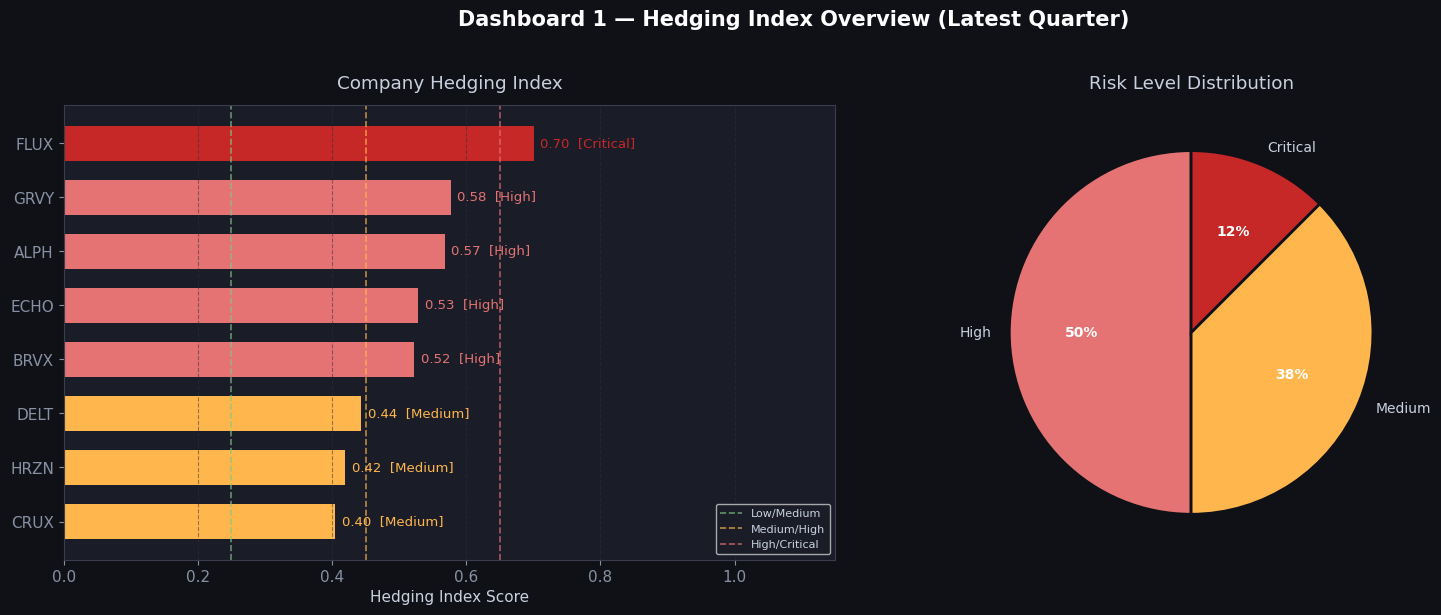

In [16]:
# DASHBOARD 1 — Overview: Hedging Index by Company

latest = df[df['quarter'] == df['quarter'].max()].sort_values('hedging_index', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Dashboard 1 — Hedging Index Overview (Latest Quarter)',
             color='white', fontsize=15, fontweight='bold', y=1.02)

#Left: Horizontal Bar Chart
ax = axes[0]
bar_colors = [RISK_COLORS[r] for r in latest['risk_level']]
bars = ax.barh(latest['ticker'], latest['hedging_index'], color=bar_colors, edgecolor='none', height=0.65)

for bar, val, risk in zip(bars, latest['hedging_index'], latest['risk_level']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}  [{risk}]', va='center', color=RISK_COLORS[risk], fontsize=9.5)

ax.axvline(0.25, color='#81c784', linewidth=1.2, linestyle='--', alpha=0.7, label='Low/Medium')
ax.axvline(0.45, color='#ffb74d', linewidth=1.2, linestyle='--', alpha=0.7, label='Medium/High')
ax.axvline(0.65, color='#e57373', linewidth=1.2, linestyle='--', alpha=0.7, label='High/Critical')
ax.set_xlabel('Hedging Index Score')
ax.set_title('Company Hedging Index', color='#c9d1e0', pad=12)
ax.set_xlim(0, 1.15)
ax.legend(fontsize=8, loc='lower right')
ax.grid(axis='x')

#Right: Risk Level Distribution Pie
ax2 = axes[1]
risk_counts = latest['risk_level'].value_counts()
pie_colors  = [RISK_COLORS[r] for r in risk_counts.index]
wedges, texts, autotexts = ax2.pie(
    risk_counts.values, labels=risk_counts.index, colors=pie_colors,
    autopct='%1.0f%%', startangle=90,
    textprops={'color': '#c9d1e0', 'fontsize': 10},
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
ax2.set_title('Risk Level Distribution', color='#c9d1e0', pad=12)

plt.tight_layout()
plt.savefig('/home/claude/dashboard1.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✓ Dashboard 1 saved.")

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/dashboard2.png'

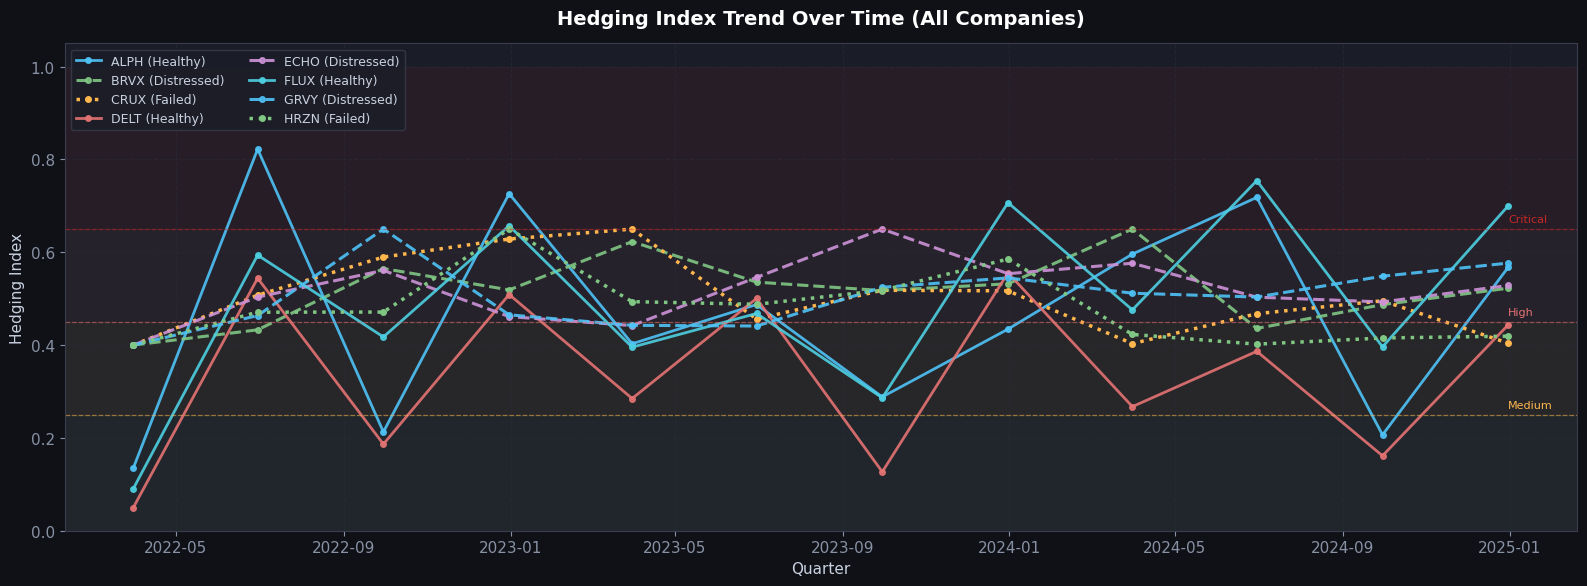

In [15]:
# DASHBOARD 2 — Hedging Index Trend Over Time (per company)

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')

profile_styles = {
    'healthy':    {'ls': '-',  'lw': 2.0, 'alpha': 0.9},
    'distressed': {'ls': '--', 'lw': 2.2, 'alpha': 0.9},
    'failed':     {'ls': ':',  'lw': 2.5, 'alpha': 1.0},
}

for i, c in enumerate(companies):
    sub = df[df['ticker'] == c['ticker']]
    style = profile_styles[c['profile']]
    ax.plot(sub['quarter'], sub['hedging_index'],
            label=f"{c['ticker']} ({c['profile'].capitalize()})",
            color=PALETTE[i % len(PALETTE)],
            linestyle=style['ls'], linewidth=style['lw'], alpha=style['alpha'],
            marker='o', markersize=4)

# Risk threshold bands
ax.axhspan(0,    0.25, alpha=0.06, color='#81c784', label='_nolegend_')
ax.axhspan(0.25, 0.45, alpha=0.06, color='#ffb74d', label='_nolegend_')
ax.axhspan(0.45, 0.65, alpha=0.06, color='#e57373', label='_nolegend_')
ax.axhspan(0.65, 1.0,  alpha=0.08, color='#c62828', label='_nolegend_')

for y, label, col in [(0.25, 'Medium', '#ffb74d'), (0.45, 'High', '#e57373'), (0.65, 'Critical', '#c62828')]:
    ax.axhline(y, color=col, linewidth=0.9, linestyle='--', alpha=0.5)
    ax.text(sub['quarter'].iloc[-1], y + 0.01, label, color=col, fontsize=8, va='bottom')

ax.set_title('Hedging Index Trend Over Time (All Companies)', color='white', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Quarter')
ax.set_ylabel('Hedging Index')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', fontsize=9, ncol=2,
          facecolor='#1a1d27', edgecolor='#3a3d4d', labelcolor='#c9d1e0')
ax.grid(True)

plt.tight_layout()
plt.savefig('/home/claude/dashboard2.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✓ Dashboard 2 saved.")

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/dashboard3.png'

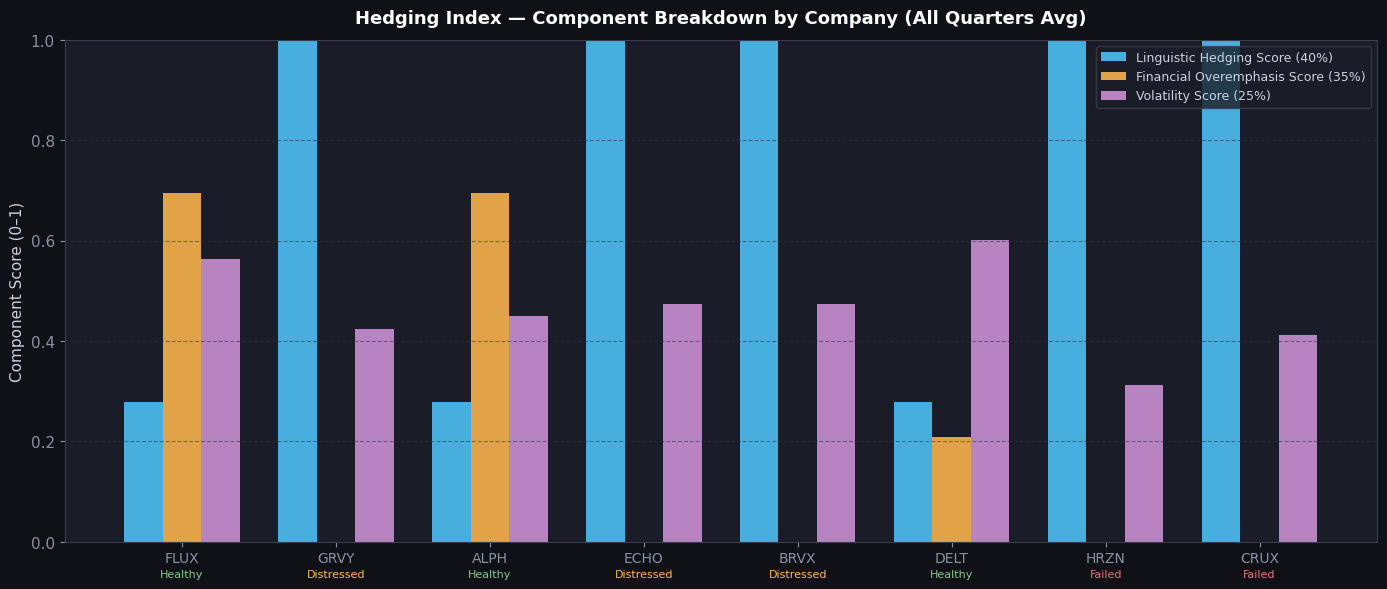

In [14]:
# DASHBOARD 3 — Hedging Index Component Breakdown

latest_mean = df.groupby('ticker')[['lhs', 'fos', 'vs']].mean().reindex(
    latest.sort_values('hedging_index', ascending=False)['ticker'])

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')

x = np.arange(len(latest_mean))
w = 0.25
component_colors = ['#4fc3f7', '#ffb74d', '#ce93d8']
labels = ['Linguistic Hedging Score (40%)', 'Financial Overemphasis Score (35%)', 'Volatility Score (25%)']

for i, (col, color, label) in enumerate(zip(['lhs', 'fos', 'vs'], component_colors, labels)):
    ax.bar(x + i*w, latest_mean[col], width=w, label=label, color=color, alpha=0.88, edgecolor='none')

ax.set_xticks(x + w)
ax.set_xticklabels(latest_mean.index, fontsize=10)
ax.set_ylabel('Component Score (0–1)')
ax.set_title('Hedging Index — Component Breakdown by Company (All Quarters Avg)',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=9, facecolor='#1a1d27', edgecolor='#3a3d4d', labelcolor='#c9d1e0')
ax.grid(axis='y')

# Annotate company profiles
profile_map = {c['ticker']: c['profile'] for c in companies}
for xi, ticker in enumerate(latest_mean.index):
    p = profile_map[ticker]
    color = {'healthy': '#81c784', 'distressed': '#ffb74d', 'failed': '#e57373'}[p]
    ax.text(xi + w, -0.07, p.capitalize(), ha='center', color=color, fontsize=8)

plt.tight_layout()
plt.savefig('/home/claude/dashboard3.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✓ Dashboard 3 saved.")

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/dashboard4.png'

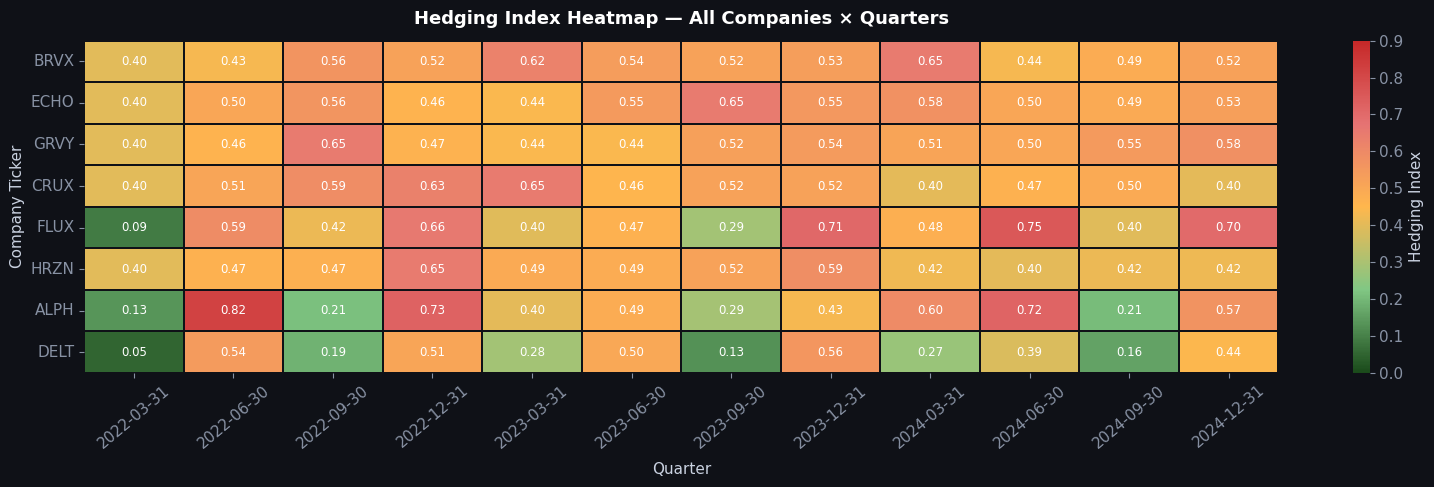

In [13]:
# DASHBOARD 4 — Risk Heatmap: All Companies × All Quarters

pivot = df.pivot_table(index='ticker', columns='quarter', values='hedging_index')
pivot.columns = [str(c.date()) for c in pivot.columns]

# Sort by average hedging index (most risky at top)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

cmap = sns.color_palette(['#1a3a1a', '#81c784', '#ffb74d', '#e57373', '#c62828'], as_cmap=False)
cmap_obj = sns.blend_palette(['#1a4a1a', '#81c784', '#ffb74d', '#e57373', '#c62828'], as_cmap=True)

sns.heatmap(
    pivot, ax=ax, cmap=cmap_obj, vmin=0, vmax=0.9,
    annot=True, fmt='.2f', annot_kws={'size': 8.5, 'color': 'white'},
    linewidths=1.2, linecolor='#0f1117',
    cbar_kws={'label': 'Hedging Index'}
)

ax.set_title('Hedging Index Heatmap — All Companies × Quarters',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Quarter', labelpad=8)
ax.set_ylabel('Company Ticker')
ax.tick_params(axis='x', rotation=40)

# Add profile labels on y-axis
ytick_labels = []
for t in pivot.index:
    p = profile_map[t]
    ytick_labels.append(t)
ax.set_yticklabels(pivot.index, rotation=0)

plt.tight_layout()
plt.savefig('/home/claude/dashboard4.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✓ Dashboard 4 saved.")

---
## Section 5: Early Warning Risk Scoring

A simple threshold-based failure probability estimator using the Hedging Index.
This will be replaced with a trained ML classifier (scikit-learn) in the final report.

In [12]:
#Risk Score: Sigmoid-weighted Hedging Index
def failure_probability(hi, sensitivity=10, threshold=0.45):
    """Sigmoid mapping from hedging index → failure probability."""
    return round(1 / (1 + np.exp(-sensitivity * (hi - threshold))), 4)

# Average HI over last 4 quarters (trailing window)
recent = df.groupby('ticker').apply(
    lambda g: g.nlargest(4, 'quarter')
).reset_index(drop=True)

risk_summary = recent.groupby('ticker').agg(
    name=('name', 'first'),
    sector=('sector', 'first'),
    profile=('profile', 'first'),
    avg_hi=('hedging_index', 'mean'),
    max_hi=('hedging_index', 'max'),
    avg_lhs=('lhs', 'mean'),
    avg_de=('debt_equity', 'mean'),
    avg_roe=('roe', 'mean'),
).reset_index()

risk_summary['failure_prob'] = risk_summary['avg_hi'].apply(failure_probability)
risk_summary['risk_level'] = risk_summary['avg_hi'].apply(classify_risk)
risk_summary = risk_summary.sort_values('failure_prob', ascending=False)

#Final Report Card
print("="*72)
print(" EARLY WARNING RISK REPORT — CS-4982 Hedging Detection System")
print("="*72)
print(f"{'Ticker':<7} {'Company':<25} {'Avg HI':>7} {'Fail Prob':>10} {'Risk':>10} {'Profile':<12}")
print("-"*72)
for _, row in risk_summary.iterrows():
    print(f"{row['ticker']:<7} {row['name']:<25} {row['avg_hi']:>7.3f} "
          f"{row['failure_prob']:>9.1%} {row['risk_level']:>10}  {row['profile']:<12}")
print("="*72)
print("Note: Failure probability uses sigmoid(HI; k=10, θ=0.45). To be replaced")
print("      with scikit-learn classifier trained on labelled EDGAR data.")

 EARLY WARNING RISK REPORT — CS-4982 Hedging Detection System
Ticker  Company                    Avg HI  Fail Prob       Risk Profile     
------------------------------------------------------------------------
FLUX    Flux Money Mgmt             0.582     78.9%       High  healthy     
GRVY    Gravity Partners            0.535     70.1%       High  distressed  
ECHO    Echo Global Fund            0.525     68.0%       High  distressed  
BRVX    Bravex Asset Mgmt           0.524     67.7%       High  distressed  
ALPH    Alpha Capital               0.522     67.3%       High  healthy     
CRUX    Crux Investments            0.443     48.1%     Medium  failed      
HRZN    Horizon Wealth              0.415     41.3%     Medium  failed      
DELT    Delta Quantitative          0.315     20.5%     Medium  healthy     
Note: Failure probability uses sigmoid(HI; k=10, θ=0.45). To be replaced
      with scikit-learn classifier trained on labelled EDGAR data.


FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/dashboard5.png'

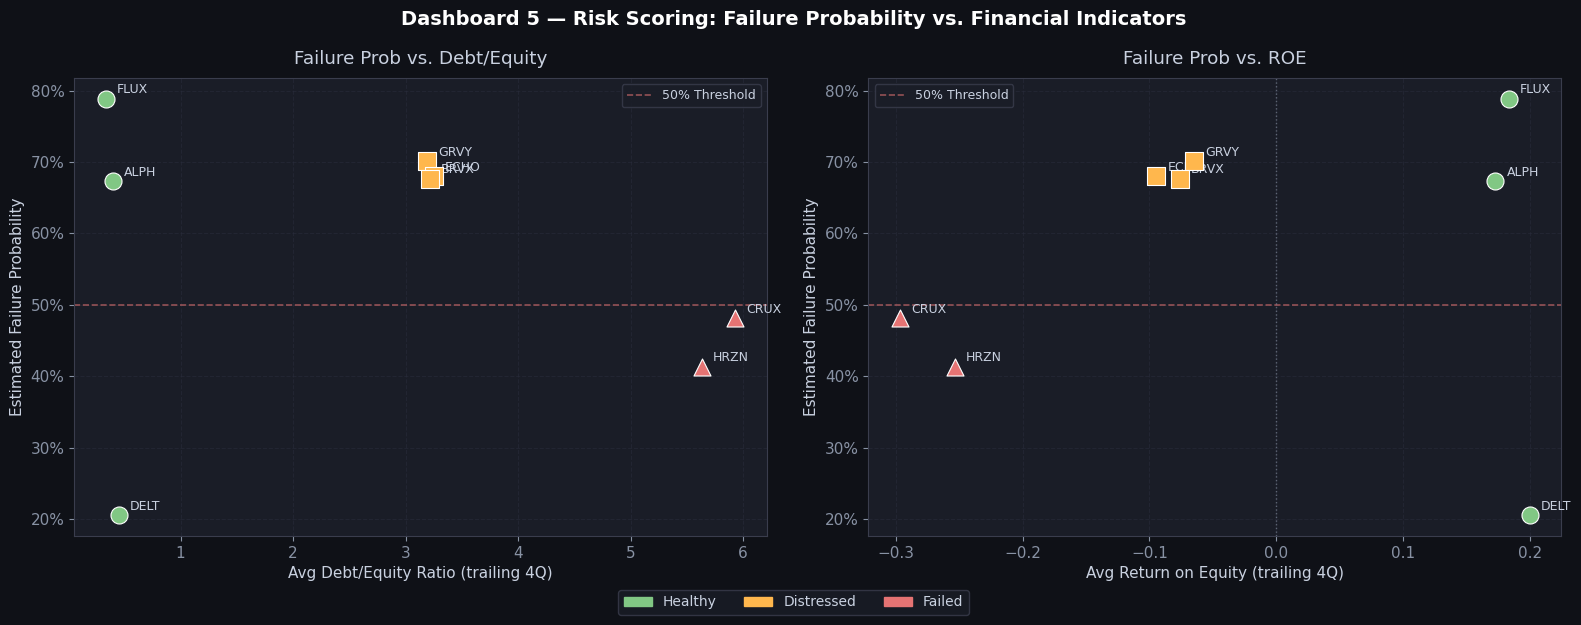

In [11]:
# DASHBOARD 5 — Failure Probability vs. Financial Health Scatter

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Dashboard 5 — Risk Scoring: Failure Probability vs. Financial Indicators',
             color='white', fontsize=14, fontweight='bold')

profile_marker = {'healthy': 'o', 'distressed': 's', 'failed': '^'}
profile_color  = {'healthy': '#81c784', 'distressed': '#ffb74d', 'failed': '#e57373'}

#Left: Failure Prob vs Debt/Equity
ax1 = axes[0]
for _, row in risk_summary.iterrows():
    ax1.scatter(row['avg_de'], row['failure_prob'],
                color=profile_color[row['profile']],
                marker=profile_marker[row['profile']],
                s=150, zorder=5, edgecolors='white', linewidth=0.8)
    ax1.annotate(row['ticker'], (row['avg_de'], row['failure_prob']),
                 textcoords='offset points', xytext=(8, 4), fontsize=9, color='#c9d1e0')

ax1.axhline(0.5, color='#e57373', linewidth=1.2, linestyle='--', alpha=0.6, label='50% Threshold')
ax1.set_xlabel('Avg Debt/Equity Ratio (trailing 4Q)')
ax1.set_ylabel('Estimated Failure Probability')
ax1.set_title('Failure Prob vs. Debt/Equity', color='#c9d1e0', pad=10)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax1.legend(fontsize=9, facecolor='#1a1d27', edgecolor='#3a3d4d', labelcolor='#c9d1e0')
ax1.grid(True)

#Right: Failure Prob vs ROE
ax2 = axes[1]
for _, row in risk_summary.iterrows():
    ax2.scatter(row['avg_roe'], row['failure_prob'],
                color=profile_color[row['profile']],
                marker=profile_marker[row['profile']],
                s=150, zorder=5, edgecolors='white', linewidth=0.8)
    ax2.annotate(row['ticker'], (row['avg_roe'], row['failure_prob']),
                 textcoords='offset points', xytext=(8, 4), fontsize=9, color='#c9d1e0')

ax2.axhline(0.5, color='#e57373', linewidth=1.2, linestyle='--', alpha=0.6, label='50% Threshold')
ax2.axvline(0, color='#8892a4', linewidth=1, linestyle=':', alpha=0.6)
ax2.set_xlabel('Avg Return on Equity (trailing 4Q)')
ax2.set_ylabel('Estimated Failure Probability')
ax2.set_title('Failure Prob vs. ROE', color='#c9d1e0', pad=10)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.legend(fontsize=9, facecolor='#1a1d27', edgecolor='#3a3d4d', labelcolor='#c9d1e0')
ax2.grid(True)

# Legend for profile markers
legend_patches = [
    mpatches.Patch(color=profile_color[p], label=p.capitalize()) for p in ['healthy', 'distressed', 'failed']
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=10,
           facecolor='#1a1d27', edgecolor='#3a3d4d', labelcolor='#c9d1e0',
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('/home/claude/dashboard5.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✓ Dashboard 5 saved.")

---
## Section 6: Next Steps

This simulation demonstrates the core pipeline. For the **final report**, the following extensions are planned:

| Task | Status | Target |
|---|---|---|
| Replace synthetic data with real EDGAR 10-K filings | 🔄 In Progress | Progress Report 2 |
| Implement Doc2Vec embeddings for richer NLP features | 📋 Planned | Essay Draft 1 |
| Train scikit-learn classifier (Logistic Regression / Random Forest) | 📋 Planned | Essay Draft 1 |
| Backtesting & sensitivity analysis | 📋 Planned | Final Draft |
| Stakeholder-facing risk dashboard (interactive) | 📋 Planned | Final Draft |

---
*Report authored by Darin Thomson — CS-4982, UNB, 2026*